In [2]:
import numpy as np
import matplotlib.pyplot as plt


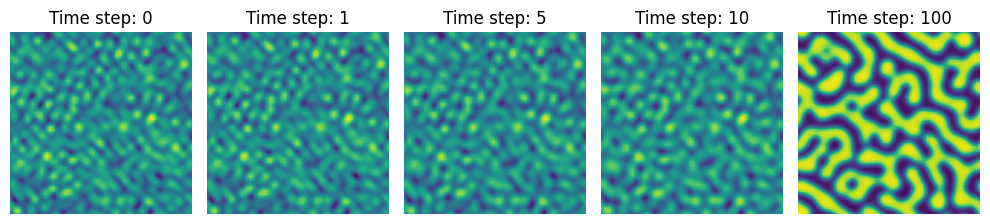

In [3]:
save_dir = "/root/autodl-tmp/data/spinodal_decomp_spectra/"
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 1, 5, 10,100]

fig, axes = plt.subplots(1, len(tics), figsize=(10, 3))
for i, tic in enumerate(tics):
    ax = axes[i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 0, ...],
                     levels=50, cmap='viridis')
    ax.set_title(f'Time step: {tic}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()

fig.tight_layout()

In [4]:
solutions.shape

(20, 101, 1, 64, 64)

In [5]:
from configs.train_debug import Configs
configs = Configs()

def prepare_data(data_dir):

    mesh = np.load(f"{data_dir}/mesh_grid_coords.npy")
    mesh = np.transpose(mesh, (2, 0, 1))
    meshx = mesh[0, :, :]
    meshy = mesh[1, :, :]
    times = np.load(f"{data_dir}/times.npy")
    dt = times[1] - times[0]
    num_times = times.shape[0]
    solutions = np.load(f"{data_dir}/solutions_grid.npy", allow_pickle=True)
    num_ics = solutions.shape[0]
    Xs = np.zeros(
        ((num_times-1)*num_ics, 3, mesh.shape[1], mesh.shape[2])
    ) 
    Ys = np.zeros(
        ((num_times-1)*num_ics, 1, mesh.shape[1], mesh.shape[2])
    )

    for i in range(num_ics):
        Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # c
        Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # c at next time step
    meshes_repeated = np.repeat(mesh[np.newaxis, :, :, :], Xs.shape[0], axis=0)
    Xs[:, 1, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
    Xs[:, 2, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y
    return Xs, Ys
Xs, Ys = prepare_data(f"{save_dir}/train_valid")
Xs_init_steps, Ys_init_steps = prepare_data(f"{save_dir}/train_init_steps")
Xs = np.concatenate([Xs, Xs_init_steps], axis=0)
Ys = np.concatenate([Ys, Ys_init_steps], axis=0)
Xs.shape, Ys.shape

((2200, 3, 64, 64), (2200, 1, 64, 64))

-0.2189300110712337 0.25431685282776734 -0.2285911461090058 0.26729835151724823 6.629043742406582e-08 0.017980707077540292
-0.278874102654568 0.33422666197666495 -0.2975114550676913 0.35403711888211964 6.962792806000651e-07 0.023032983968388265
-0.3653527398826448 0.41991521986456803 -0.3898428348867784 0.4437340584506132 2.7916881238376767e-06 0.031777217066759955


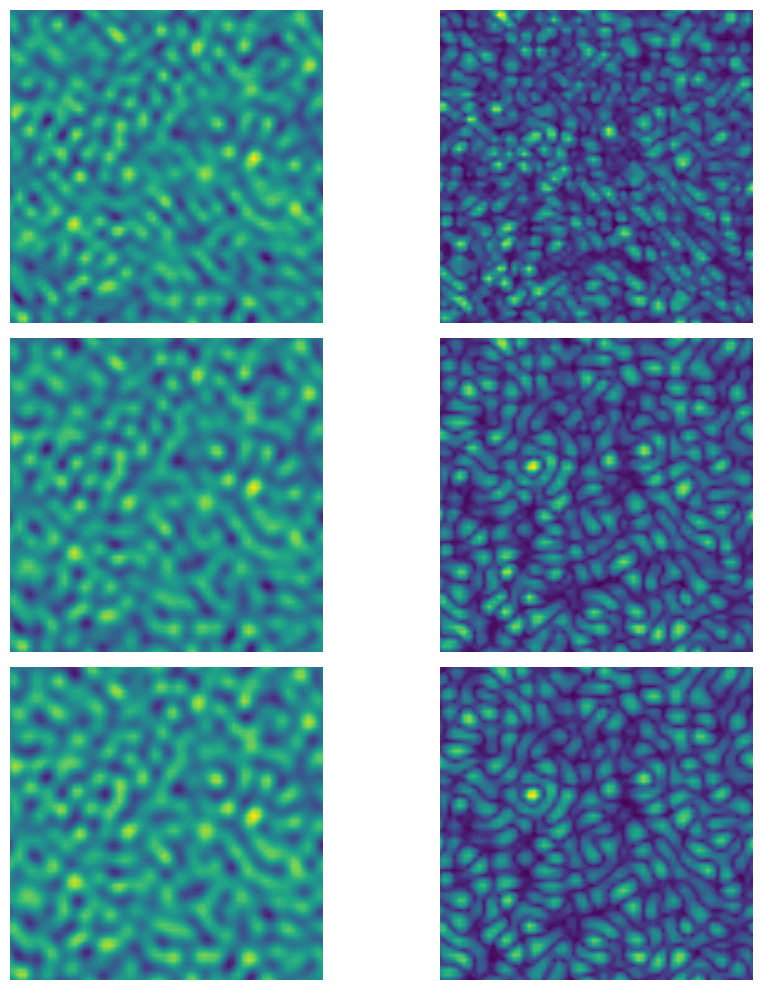

In [6]:
import matplotlib.pyplot as plt
ts = [0, 5, 9]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 0
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 1, :, :] * configs.Lc
    meshy = Xs[t, 2, :, :] * configs.Lc
    ax = axes[idx, 0]
    # im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.contourf(meshx, meshy, x, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    # im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.contourf(meshx, meshy, diff, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()
    print(x.min(), x.max(), y.min(), y.max(), diff.min(), diff.max())
fig.tight_layout()


[0.00438001 0.00459683 0.00488911 0.00524743 0.00566283 0.00613139
 0.00665001 0.00721482 0.00782588 0.00848213 0.00918068 0.00991749
 0.01068755 0.01148389 0.01229584 0.01311293 0.01392078 0.01470266
 0.01543891 0.01610822]


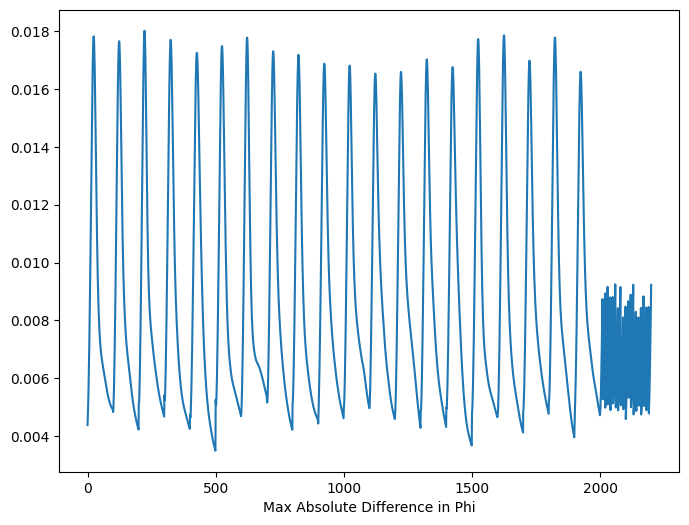

In [7]:

diffs = Xs[:, 0, ...] - Ys[:, 0, ...]
diffs = np.abs(diffs)

# diffs[:, 0].max(), diffs[:, 1].max(), diffs[:, 0].min(), diffs[:, 1].min()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.plot(diffs.mean(axis=(-1,-2)))
ax.set_xlabel('Max Absolute Difference in Phi')
print(np.mean(diffs, axis=(-1,-2))[:20])

In [8]:
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
dt

np.float64(5e-05)

In [9]:
np.savez(
    "/root/autodl-tmp/data/spinodal_decomp_spectra/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [10]:
Xs.shape, Ys.shape

((2200, 3, 64, 64), (2200, 1, 64, 64))

In [11]:


dx = mesh[0, 0, 1] - mesh[0, 0, 0]
dy = mesh[1, 1, 0] - mesh[1, 0, 0]
dx = dx / configs.Lc
dy = dy / configs.Lc
dt = times[1] - times[0]
dt = dt / configs.Tc
print(dx, dy, dt)



0.015625 0.015625 0.5


In [23]:
nx = mesh.shape[2]
ny = mesh.shape[1]
lx = 1.0
ly = 1.0
kx = 2 * np.pi * np.fft.fftfreq(nx, d=lx/nx)
ky = 2 * np.pi * np.fft.fftfreq(ny, d=ly/ny)
KX, KY = np.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2

In [25]:
x0 = Xs[0]
c0 = x0[0, :, :]

pred = Ys[0]
c = pred[0, :, :]

# 重新获取原始 dt
dt = times[1] - times[0]

# 计算控制方程残差 (Residual of Governing Equation)
# 方程: dc/dt = M * laplacian(mu)
# 采用半隐式格式: (c - c0)/dt = M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)

# 1. 转到频域
c0_hat = np.fft.fft2(c0)
c_hat = np.fft.fft2(c)

# 2. 计算 LHS: dc/dt
lhs_hat = (c_hat - c0_hat) / dt

# 3. 计算 RHS: M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)
# 注意：laplacian -> -K2, bi-laplacian -> K4
M = 1.0
lambda_param = 0.01**2

f_prime = c0**3 - c0
f_prime_hat = np.fft.fft2(f_prime)

# M * laplacian(f'(c0)) -> M * (-K2) * f_prime_hat
term1_hat = -M * K2 * f_prime_hat

# - M * lambda * bi-laplacian(c) -> - M * lambda * (K4) * c_hat
# 注意这里使用的是新时刻的 c (隐式项)
term2_hat = -M * lambda_param * K4 * c_hat

rhs_hat = term1_hat + term2_hat

# 4. 计算残差 (LHS - RHS)
res_hat = lhs_hat - rhs_hat
residual = np.fft.ifft2(res_hat).real

# 打印统计
print(f"Residual Max: {np.max(np.abs(residual))}")
print(f"Residual Mean: {np.mean(np.abs(residual))}")

# 取绝对值用于后续绘图
residual = np.abs(residual)

Residual Max: 9.4634520728721e-12
Residual Mean: 1.857125950964157e-12


In [28]:
dx, dy, dt

(np.float64(0.015625), np.float64(0.015625), np.float64(5e-05))

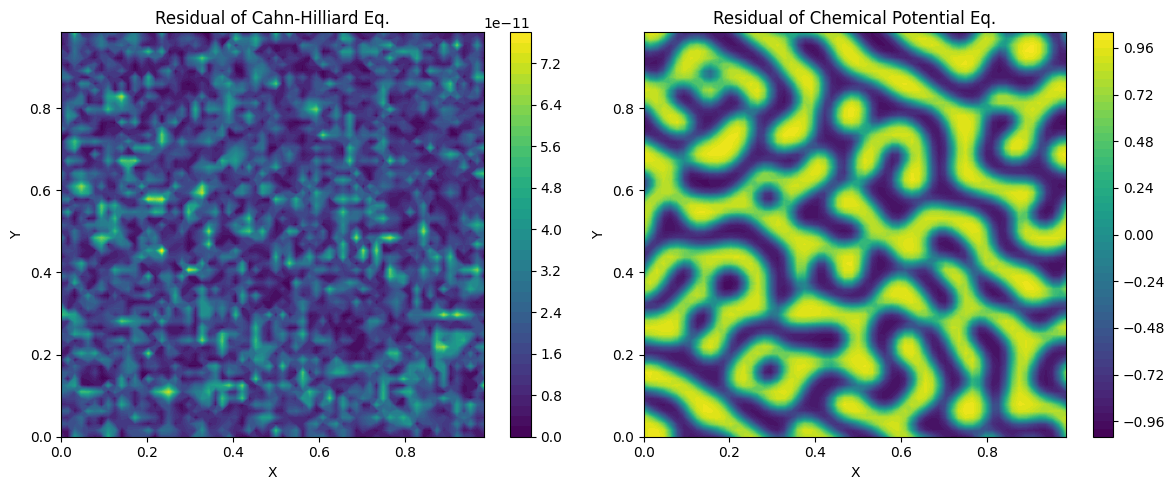

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
im = ax.contourf(meshx, meshy, residual, levels=50, cmap='viridis')
ax.set_title('Residual of Cahn-Hilliard Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.contourf(meshx, meshy, c, levels=50, cmap='viridis')
ax.set_title('Residual of Chemical Potential Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)
fig.tight_layout()

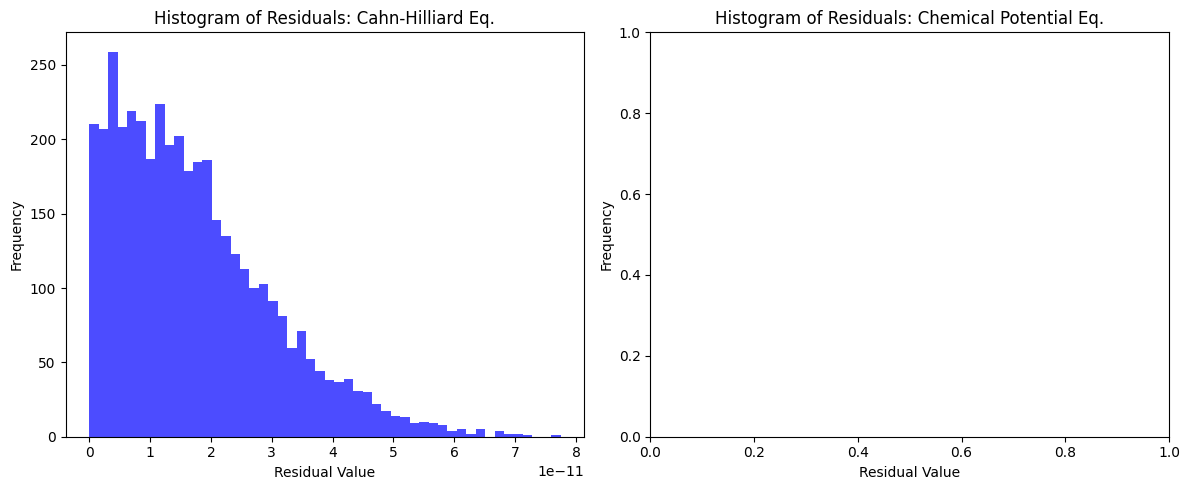

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.hist(residual.flatten(), bins=50, color='blue', alpha=0.7)
ax.set_title('Histogram of Residuals: Cahn-Hilliard Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')

ax = axes[1]
# ax.hist(residual2.flatten(), bins=50, color='green', alpha=0.7)
ax.set_title('Histogram of Residuals: Chemical Potential Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')
fig.tight_layout()

Mass Min: -1.776357e-13
Mass Max: 5.684342e-14
Mass Fluctuation (Max-Min): 2.344791e-13


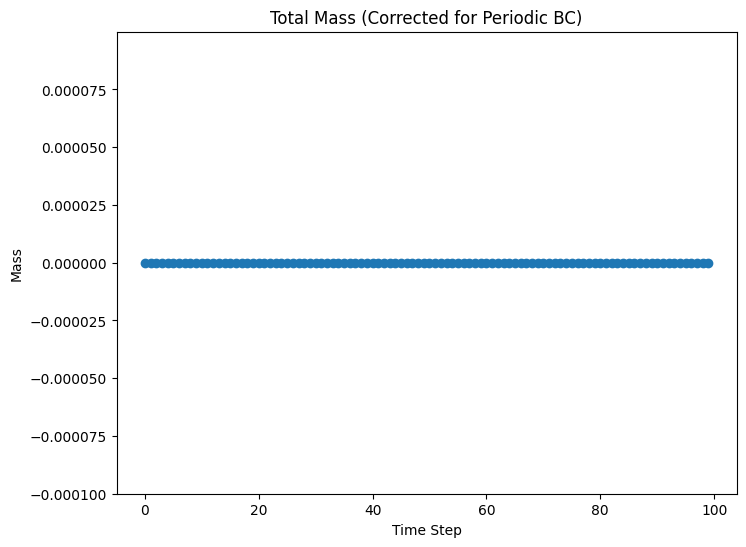

In [17]:

cs_inner = Xs[0:100, 0,] 

# 2. 计算质量
mass = np.sum(cs_inner, axis=(-1, -2))

# 3. 打印统计信息
print(f"Mass Min: {mass.min():.6e}")
print(f"Mass Max: {mass.max():.6e}")
print(f"Mass Fluctuation (Max-Min): {mass.max() - mass.min():.6e}")

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mass, marker='o')
# 限制 y 轴范围以便看清是否是机器误差级别的波动
mean_mass = mass.mean()
ax.set_ylim(mean_mass - 1e-4, mean_mass + 1e-4) 
ax.set_title('Total Mass (Corrected for Periodic BC)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Mass')
plt.show()